# F Distribution

The **F distribution** is the ratio of two independent chi-square variables divided by their degrees of freedom. It is right-skewed, positive, and is the foundation of **ANOVA** and regression **F-tests** for comparing variances.

| Property | Value |
|---|---|
| **Parameters** | ν₁ (numerator df), ν₂ (denominator df) |
| **Support** | (0, +∞) |
| **Definition** | F = (χ²(ν₁)/ν₁) / (χ²(ν₂)/ν₂) |
| **Mean** | ν₂/(ν₂−2) for ν₂ > 2 |
| **Mode** | (ν₁−2)/ν₁ · ν₂/(ν₂+2) for ν₁ > 2 |
| **Skewness** | Right-skewed (positive) |
| **Reciprocal** | If X ~ F(ν₁,ν₂), then 1/X ~ F(ν₂,ν₁) |
| **Primary use** | ANOVA, regression F-test, testing equality of variances |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

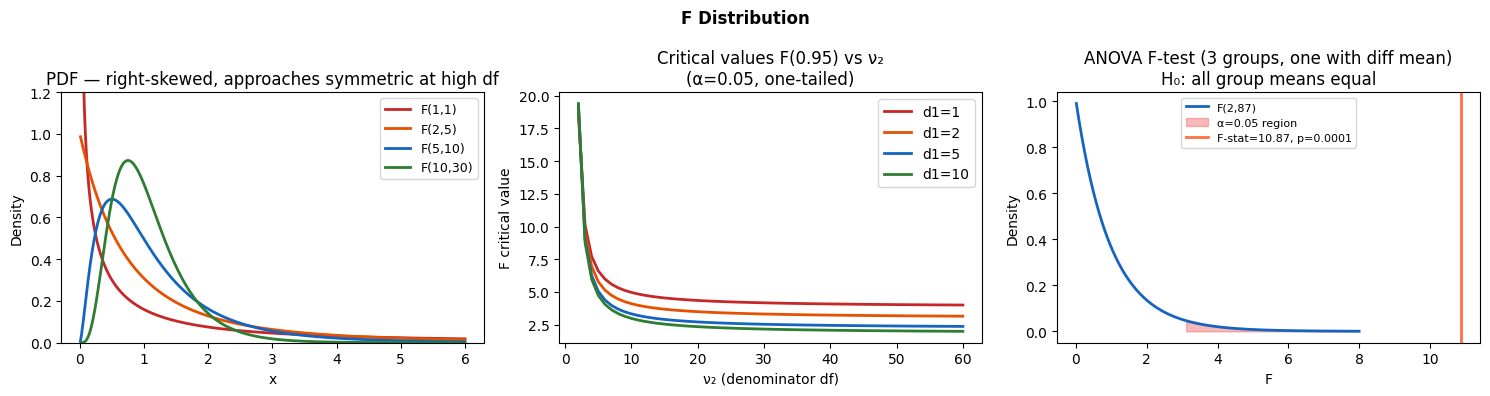

ANOVA: F=10.872, p=0.00006
Critical F(0.95, 2, 87) = 3.101
Group means: G1=9.62, G2=11.76, G3=10.03


In [2]:
x = np.linspace(0.01, 6, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('F Distribution', fontsize=12, fontweight='bold')

# PDF — various (d1, d2)
for d1, d2, color, label in [(1,  1,  '#C62828', 'F(1,1)'),
                               (2,  5,  '#E65100', 'F(2,5)'),
                               (5,  10, '#1565C0', 'F(5,10)'),
                               (10, 30, '#2E7D32', 'F(10,30)')]:
    axes[0].plot(x, stats.f(d1, d2).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — right-skewed, approaches symmetric at high df')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 1.2)
axes[0].legend(fontsize=9)

# Critical value surface at α=0.05
df1_vals = [1, 2, 3, 5, 10, 20]
df2_vals = np.arange(2, 61)
for d1, color in zip([1, 2, 5, 10], ['#C62828','#E65100','#1565C0','#2E7D32']):
    crits = [stats.f(d1, d2).ppf(0.95) for d2 in df2_vals]
    axes[1].plot(df2_vals, crits, color=color, linewidth=2, label=f'd1={d1}')
axes[1].set_title('Critical values F(0.95) vs ν₂\n(α=0.05, one-tailed)')
axes[1].set_xlabel('ν₂ (denominator df)')
axes[1].set_ylabel('F critical value')
axes[1].legend()

# ANOVA F-test demonstration — 3 groups
np.random.seed(42)
g1 = np.random.normal(10, 2, 30)
g2 = np.random.normal(12, 2, 30)  # group 2 has a different mean
g3 = np.random.normal(10, 2, 30)
f_stat, p_val = stats.f_oneway(g1, g2, g3)
df1_anova = 2    # k-1 = 3-1
df2_anova = 87   # n-k = 90-3
f_range = np.linspace(0.01, 8, 400)
axes[2].plot(f_range, stats.f(df1_anova, df2_anova).pdf(f_range),
             color='#1565C0', linewidth=2, label=f'F({df1_anova},{df2_anova})')
f_crit = stats.f(df1_anova, df2_anova).ppf(0.95)
axes[2].fill_between(f_range, stats.f(df1_anova, df2_anova).pdf(f_range),
                     where=(f_range >= f_crit),
                     color='#EF5350', alpha=0.4, label=f'α=0.05 region')
axes[2].axvline(f_stat, color='#FF7043', linewidth=2,
                label=f'F-stat={f_stat:.2f}, p={p_val:.4f}')
axes[2].set_title('ANOVA F-test (3 groups, one with diff mean)\nH₀: all group means equal')
axes[2].set_xlabel('F'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"ANOVA: F={f_stat:.3f}, p={p_val:.5f}")
print(f"Critical F(0.95, 2, 87) = {f_crit:.3f}")
print(f"Group means: G1={g1.mean():.2f}, G2={g2.mean():.2f}, G3={g3.mean():.2f}")

## Key Takeaways

| | |
|---|---|
| **Definition** | Ratio of two chi-square variables ÷ their df |
| **Shape** | Right-skewed; becomes more symmetric as ν₁, ν₂ → ∞ |
| **ANOVA** | F = MSB/MSW — between-group variance / within-group variance |
| **Regression** | F = (R²/k) / ((1−R²)/(n−k−1)) — tests if model explains variance |
| **Variance test** | F = s₁²/s₂² ~ F(n₁−1, n₂−1) under H₀: σ₁²=σ₂² |
| **Reciprocal** | 1/F(ν₁,ν₂) ~ F(ν₂,ν₁) — use upper tail for both-directional variance tests |
| **Relationship** | t²(ν) = F(1, ν) — the t-test is a special case of the F-test |